Mounted at /content/drive
anomaly
 1    15927
-1       48
Name: count, dtype: int64

top 50 anomalies (isolation forest):
                     date     score  anomaly
27    2025-02-01 02:15:00  0.021265       -1
29    2025-02-01 02:25:00  0.003696       -1
35    2025-02-01 02:55:00  0.004204       -1
36    2025-02-01 03:00:00  0.017822       -1
37    2025-02-01 03:05:00  0.006387       -1
40    2025-02-01 03:20:00  0.001765       -1
41    2025-02-01 03:25:00  0.004958       -1
42    2025-02-01 03:30:00  0.015195       -1
45    2025-02-01 03:50:00  0.005035       -1
49    2025-02-01 04:10:00  0.004912       -1
50    2025-02-01 04:15:00  0.011830       -1
53    2025-02-01 04:30:00  0.009266       -1
54    2025-02-01 04:35:00  0.014657       -1
55    2025-02-01 04:40:00  0.008260       -1
56    2025-02-01 04:45:00  0.020277       -1
59    2025-02-01 05:00:00  0.008753       -1
62    2025-02-01 05:15:00 -0.000003        1
65    2025-02-01 05:30:00 -0.000155        1
1134  2025-02-05 00:15:

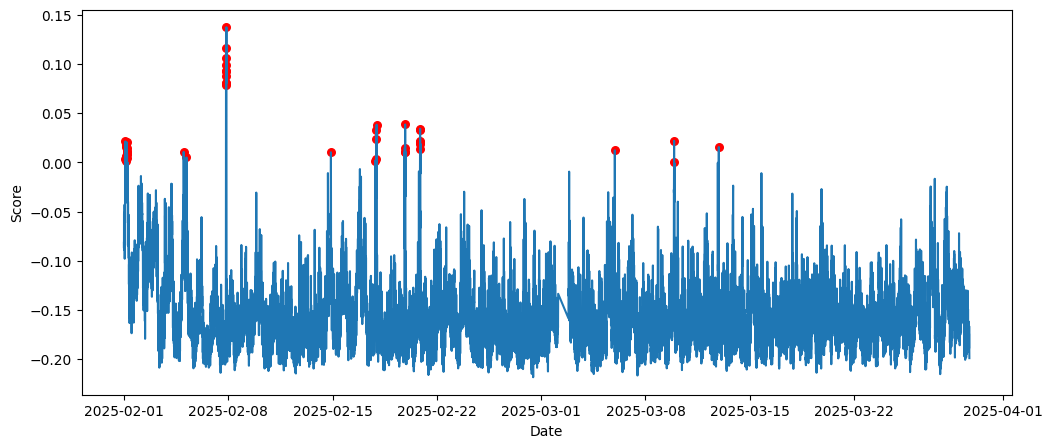

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
import torch
import torch.nn as nn
import torch.fft
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed

from google.colab import drive
drive.mount('/content/drive')
path = "/content/drive/MyDrive/data_hl19.csv"

#1. Đọc dữ liệu
data = pd.read_csv(path)
# Read data again to keep the 'date' column for output
data_with_date = pd.read_csv(path)
data_with_date['date'] = pd.to_datetime(data_with_date['date'])


# CONFIG

MODEL_TYPE = "AE-LSTM" #(IF / KMEANS / LSTM/ XGB / TIMENET / AE-LSTM)
N_COMPONENTS = 5
TEST_SIZE = 0.2
EPOCHS = 30
K_CLUSTERS = 2
TIME_STEPS = 10 # Number of time steps for AE-LSTM


feature_drop = ['date']
data.drop(columns=feature_drop, inplace=True)

X = data.drop('SGW BEARER SR', axis=1)
y = data['SGW BEARER SR']

# pca = pca(n_components=n_components)
# x_pca = pca.fit_transform(x)
# x = pd.dataframe(x_pca, columns=[f'pc{i+1}' for i in range(n_components)])

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=TEST_SIZE, random_state=42)

#  CHỈ CÓ THỂ DETECT ANOMALY TRÊN PHẦN DỮ LIỆU ĐƯỢC FORECAST
if MODEL_TYPE == "LSTM":
    # reshape dữ liệu 3d cho lstm
    x_train_lstm = X_train.values.reshape(X_train.shape[0], 1, X_train.shape[1])
    x_all = X.values.reshape(X.shape[0], 1, X.shape[1])
    x_test_lstm = X_test.values.reshape(X_test.shape[0], 1, X_test.shape[1])

    # tạo model
    model = Sequential([
        LSTM(128, activation='relu', input_shape=(1, x_train_lstm.shape[2]), return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # huấn luyện
    history = model.fit(x_train_lstm, y_train, epochs=EPOCHS, batch_size=32,
                        validation_data=(x_test_lstm, y_test), verbose=1)

    # đánh giá
    loss = model.evaluate(x_test_lstm, y_test, verbose=0)
    print(f"test loss (mse): {loss[0]:.4f}")
    print(f"test mae: {loss[1]:.4f}")


    # dự đoán và trực quan
    #y_pred = model.predict(x_test_lstm)
    y_all_pred = model.predict(x_all)
    plt.plot(y.values, label='true')
    plt.plot(y_all_pred.flatten(), label='predicted') # flatten y_pred for plotting
    plt.legend()
    plt.title("lstm prediction vs true values")
    plt.show()


elif MODEL_TYPE == "KMEANS":


    dates = data_with_date['date']
    kmeans = KMeans(n_clusters=K_CLUSTERS, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    sil_score = silhouette_score(X, cluster_labels)
    print(f"Silhouette score (k={K_CLUSTERS}): {sil_score:.4f}")

    centers = kmeans.cluster_centers_
    distances = np.linalg.norm(X - centers[cluster_labels], axis=1)

    threshold = np.percentile(distances, 97)
    anomalies = distances > threshold

    print(f"Số điểm bất thường: {np.sum(anomalies)} / {len(X)}")

    data_with_anomaly = data.copy()
    data_with_anomaly["cluster"] = cluster_labels
    data_with_anomaly["score"] = distances
    data_with_anomaly["anomaly_flag"] = anomalies.astype(int)
    # Add the 'date' column back to data_with_anomaly
    data_with_anomaly['date'] = data_with_date['date']
    data_with_anomaly = data_with_anomaly.sort_values("score", ascending=False).head(50)
    data_with_anomaly = data_with_anomaly.sort_values("date")
    print(data_with_anomaly[['date', 'score']])

    plt.figure(figsize=(12, 5))
    plt.plot(dates, distances, label='distance to cluster center', color='blue')
    plt.scatter(dates[anomalies], distances[anomalies], color='red', label='anomalies', s=50)
    plt.title("KMeans anomaly score over time")
    plt.xlabel("Date")
    plt.ylabel("Distance to cluster center")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



elif MODEL_TYPE == "AE-LSTM": # isolation forest
    iso = IsolationForest( n_estimators=100,contamination=0.003,random_state=42)
    iso.fit(X)
    y_pred = iso.fit_predict(X)

    data_with_date['anomaly'] = y_pred
    data_with_date['score'] = iso.decision_function(X) * -1

    print(data_with_date['anomaly'].value_counts())
    plt.figure(figsize=(12, 5))
    plt.plot(data_with_date['date'], data_with_date['score'], label='Anomaly Score')
    plt.scatter(
        data_with_date[data_with_date['anomaly'] == -1]['date'],
        data_with_date[data_with_date['anomaly'] == -1]['score'],
        color='red', label='Anomaly', s=30
    )
    plt.xlabel('Date')
    plt.ylabel('Score')

    top_anomalies = data_with_date.sort_values('score', ascending=False).head(50)
    top_anomalies = top_anomalies.sort_values('date').head(50)
    print("\ntop 50 anomalies (isolation forest):")
    print(top_anomalies[['date', 'score', 'anomaly']])

elif MODEL_TYPE == "XGB":
    from xgboost import XGBRegressor
    xgb = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42
    )

    # chia train/test
    x_train_xgb, x_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, shuffle=False, test_size=TEST_SIZE)

    xgb.fit(x_train_xgb, y_train_xgb)
    y_pred_xgb = xgb.predict(x_test_xgb)

    # đánh giá
    mse = mean_squared_error(y_test_xgb, y_pred_xgb)
    mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
    print(f"mse: {mse:.4f}, mae: {mae:.4f}")
    error = np.abs(y_test_xgb.values - y_pred_xgb)

    rate = 0.05 # lấy 5% anomaly top error
    threshold = np.percentile(error, 100 * (1 - rate))
    anomaly = (error > threshold).astype(int)

    plt.figure(figsize=(12,6))
    plt.plot(y_test_xgb.values, label='True', color='blue')
    plt.plot(y_pred_xgb, label='Predicted', color='orange')
    plt.scatter(
        np.where(anomaly==1),
        y_test_xgb.values[anomaly==1],
        color='red', label='Anomaly', marker='o'
    )
    plt.title("XGBoost Forecast & Anomaly Detect (rate=0.05)")
    plt.legend()
    plt.show()

elif MODEL_TYPE == "TIMENET":  #(CHỈ FORECAST TRÊN TẬP TEST NHƯ ISOLATION FOREST)
    class InceptionBlock(nn.Module):
        def __init__(self, in_channels, out_channels):
            super().__init__()
            self.branch1 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=(1, 3), padding=(0, 1))
            self.branch2 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=(1, 5), padding=(0, 2))
            self.branch3 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=(1, 7), padding=(0, 3))
            self.branch4 = nn.Conv2d(in_channels, out_channels // 4, kernel_size=(1, 1))
            self.bn = nn.BatchNorm2d(out_channels)
            self.relu = nn.ReLU()

        def forward(self, x):
            out = torch.cat([
                self.branch1(x),
                self.branch2(x),
                self.branch3(x),
                self.branch4(x)
            ], dim=1)
            return self.relu(self.bn(out))


    class TimesBlock(nn.Module):
        def __init__(self, in_channels, out_channels, top_k=3):
            super().__init__()
            self.top_k = top_k
            self.inception = InceptionBlock(in_channels, out_channels)
            self.proj = nn.Linear(out_channels, in_channels)
            self.relu = nn.ReLU()

        def forward(self, x):
            B, L, C = x.shape
            freq = torch.fft.rfft(x, dim=1)
            mag = torch.abs(freq).mean(dim=-1)
            k = min(self.top_k, mag.shape[1])
            if k == 0:
                return x
            topk = torch.topk(mag, k=k, dim=1).indices

            patches = []
            for i in range(k):
                p = topk[:, i].float()
                period = int(p.mean().item()) + 1
                period = max(2, min(period, L))
                num_patch = L // period
                if num_patch == 0:
                    continue
                actual_len = num_patch * period
                patch = x[:, :actual_len, :]
                patch = patch.reshape(B, num_patch, period, C)
                patch = patch.permute(0, 3, 1, 2)
                patches.append(patch)

            if len(patches) == 0:
                return x

            x2d = torch.stack(patches, dim=0).mean(dim=0)

            out = self.inception(x2d)
            out = out.mean(dim=(2, 3))
            out = self.proj(out)
            out = out + x.mean(dim=1)
            return self.relu(out.unsqueeze(1).repeat(1, L, 1))


    class TimeNet(nn.Module):
        def __init__(self, input_dim, hidden_dim=128, num_blocks=3):
            super().__init__()
            self.input_proj = nn.Linear(input_dim, hidden_dim)
            self.blocks = nn.ModuleList([
                TimesBlock(hidden_dim, hidden_dim, top_k=3)
                for _ in range(num_blocks)
            ])
            self.output = nn.Sequential(
                nn.Linear(hidden_dim, 64),
                nn.ReLU(),
                nn.Linear(64, 32)
            )

        def forward(self, x):
            x = self.input_proj(x)
            for block in self.blocks:
                x = block(x)
            emb = self.output(x.mean(dim=1))
            return emb

    model = TimeNet(input_dim=X_train.shape[1])
    model.eval()

    with torch.no_grad():
        X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32).unsqueeze(1)
        train_emb = model(X_train_tensor).numpy()
        test_emb = model(X_test_tensor).numpy()

    iso = IsolationForest(contamination=0.05, random_state=42)
    iso.fit(train_emb)
    test_scores = -iso.decision_function(test_emb)
    preds = iso.predict(test_emb)

    mae_emb = mean_absolute_error(train_emb.mean(axis=0), test_emb.mean(axis=0))
    mse_emb = mean_squared_error(train_emb.mean(axis=0), test_emb.mean(axis=0))
    print(f"MAE (Embedding): {mae_emb:.4f}")
    print(f"MSE (Embedding): {mse_emb:.4f}")

    df_result = pd.DataFrame({
        'date': data_with_date.iloc[len(X_train):]['date'].values,
        'score': test_scores,
        'anomaly': preds
    })

    df_result['date'] = pd.to_datetime(df_result['date'])
    df_result = df_result.sort_values(by='score', ascending=False).head(50)
    df_result = df_result.sort_values(by='date')


    print(df_result)

    plt.figure(figsize=(12, 5))
    plt.plot(df_result['date'], df_result['score'], label='Anomaly Score')
    plt.scatter(
        df_result[df_result['anomaly'] == -1]['date'],
        df_result[df_result['anomaly'] == -1]['score'],
        color='red', label='Anomaly', s=30
    )
    plt.xlabel('Date')
    plt.ylabel('Score')
    plt.title('TimeNet Anomaly Scores Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()


elif MODEL_TYPE == "AE-LSTM":

    time_steps = TIME_STEPS # Config
    n_features = X_train.shape[1]

    def create_sequences(X, time_steps=time_steps):
        Xs = []
        for i in range(len(X) - time_steps):
            Xs.append(X[i:(i + time_steps)])
        return np.array(Xs)

    X_train_seq = create_sequences(X_train.values, time_steps)
    X_test_seq = create_sequences(X_test.values, time_steps)

    model = Sequential([
        LSTM(64, activation='relu', input_shape=(time_steps, n_features), return_sequences=False),
        RepeatVector(time_steps),
        LSTM(64, activation='relu', return_sequences=True),
        TimeDistributed(Dense(n_features))
    ])

    model.compile(optimizer='adam', loss='mae')

    history = model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=32, validation_split=0.1, shuffle=False) #epochs config = 30
# thêm để detect trên toàn bộ
    X_all_seq = create_sequences(X.values, time_steps)
    X_all_pred = model.predict(X_all_seq, verbose=0)
    X_test_pred = model.predict(X_test_seq)


    reconstruction_error = np.mean(np.abs(X_all_pred - X_all_seq), axis=(1, 2))

    threshold = np.percentile(reconstruction_error, 97)
    anomalies = reconstruction_error > threshold

    start_idx = len(X_train) + time_steps
    end_idx = start_idx + len(reconstruction_error)
    valid_dates = data_with_date['date'].iloc[time_steps:].values # dùng cho việc predict lại toàn bộ

# đinh nghia lại dataframe anomaly
    df_anomaly_aelstm = pd.DataFrame({
        #'date': data_with_date['date'].iloc[start_idx:end_idx].values,
        'date': valid_dates,
        'reconstruction_error': reconstruction_error,
        'anomaly': anomalies.astype(int)
    })
    #df_anomaly_aelstm['date'] = data_with_date['date'].iloc[len(X_train) + time_steps : len(X_train) + time_steps + len(reconstruction_error)].values
    df_anomaly_aelstm['date'] = data_with_date['date']

    print("\nAE-LSTM Anomaly Detection:")
    print(df_anomaly_aelstm['anomaly'].value_counts())

    plt.figure(figsize=(12, 5))
    plt.plot(df_anomaly_aelstm['date'], df_anomaly_aelstm['reconstruction_error'], label='Reconstruction Error')
    plt.scatter(
        df_anomaly_aelstm[df_anomaly_aelstm['anomaly'] == 1]['date'],
        df_anomaly_aelstm[df_anomaly_aelstm['anomaly'] == 1]['reconstruction_error'],
        color='red', label='Anomaly', s=30
    )
    plt.xlabel('Date')
    plt.ylabel('Reconstruction Error')
    plt.title('AE-LSTM Anomaly Detection Over Time')
    plt.legend()
    plt.grid(True)
    plt.show()